# Level 2 — Task 2: Time Series Analysis
**Codveda Technology | Data Analytics Internship**

> **Dataset:** `2_Stock_Prices_Data_Set.csv` (AAPL) | **Tools:** Python, pandas, matplotlib, statsmodels
>
> **Objective:** Plot time-series data, identify patterns, decompose into trend/seasonality/residuals, and apply moving average smoothing.


## Step 1 — Imports and Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings, os

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False
})

os.makedirs("outputs/level2/timeseries_plots", exist_ok=True)

TICKER = "AAPL"

print("Ready.")

Ready.


## Step 2 — Load and Filter AAPL Data

In [7]:
df_all = pd.read_csv("2_Stock_Prices_Data_Set.csv", parse_dates=["date"])
df = df_all[df_all["symbol"] == TICKER].copy()
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"AAPL records : {len(df)}")
print(f"Date range   : {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

AAPL records : 1007
Date range   : 2014-01-02 → 2017-12-29


,symbol,date,open,high,low,close,volume
0,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
1,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
2,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
3,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
4,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


## Step 3 — Plot Raw Price and Volume

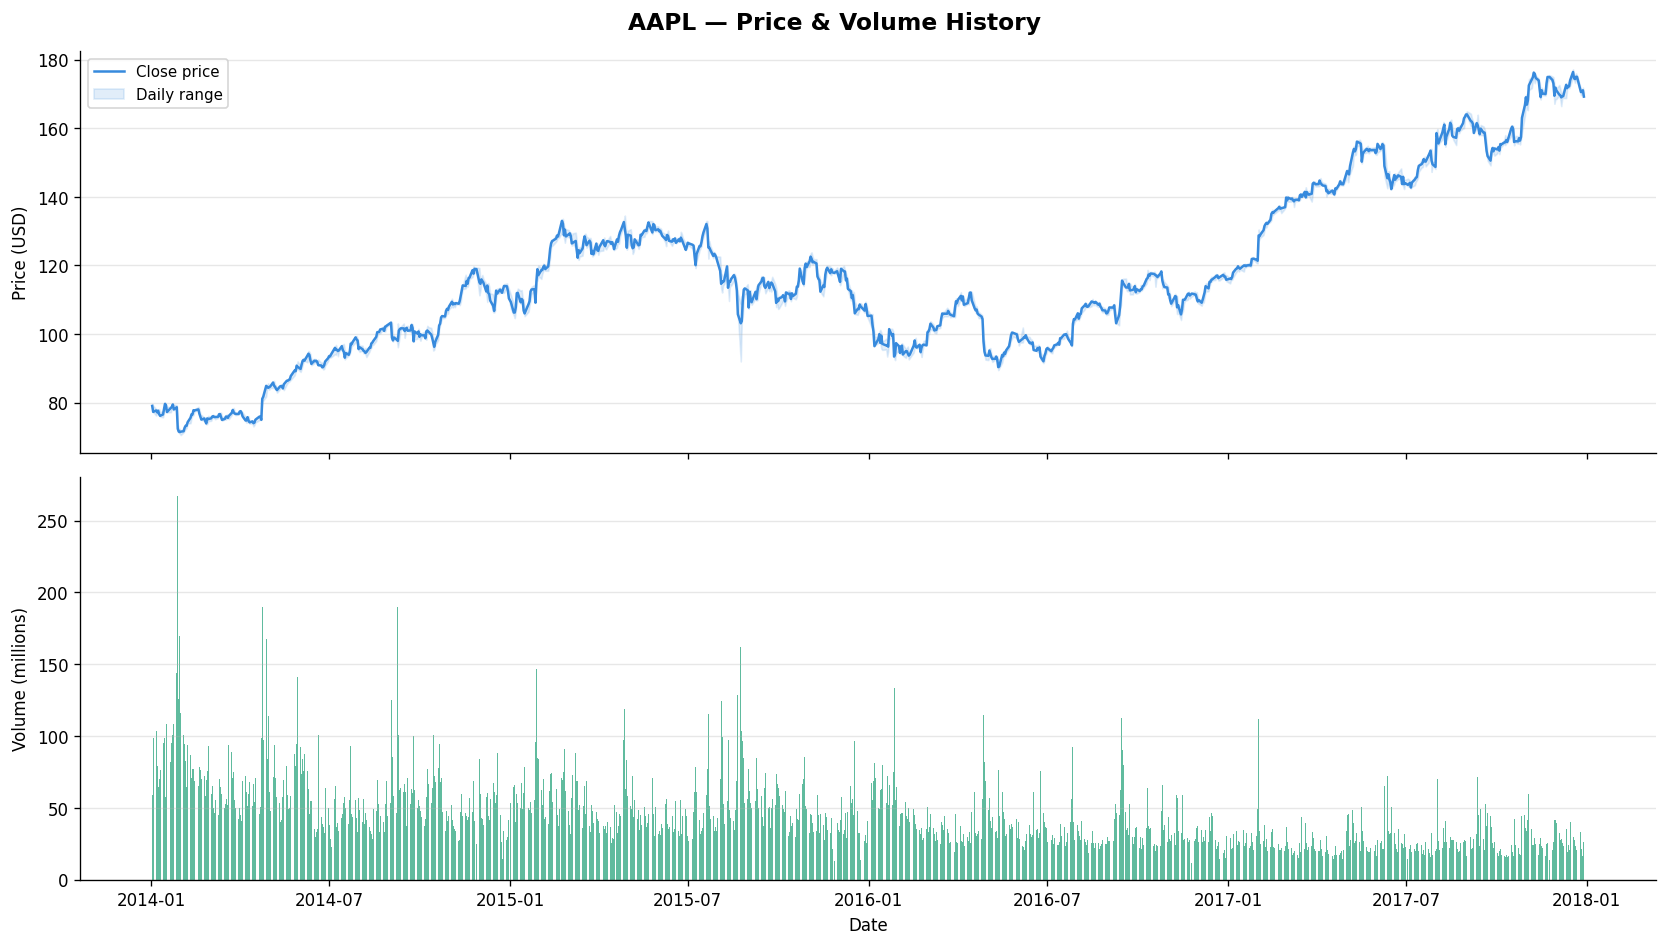

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"{TICKER} — Price & Volume History", fontsize=14, fontweight="bold")

ax = axes[0]
ax.plot(df["date"], df["close"], color="#378ADD", lw=1.5, label="Close price")
ax.fill_between(df["date"], df["low"], df["high"], alpha=0.15, color="#378ADD", label="Daily range")
ax.set_ylabel("Price (USD)"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(df["date"], df["volume"]/1e6, color="#1D9E75", alpha=0.7, width=1)
ax.set_ylabel("Volume (millions)"); ax.set_xlabel("Date"); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/level2/timeseries_plots/01_raw_price_volume.png")
plt.show()

## Step 4 — Returns and Volatility

In [9]:
df["daily_return"] = df["close"].pct_change() * 100
df["log_return"]   = np.log(df["close"] / df["close"].shift(1))

annual_return = df["log_return"].mean() * 252 * 100
annual_vol    = df["log_return"].std() * np.sqrt(252) * 100

print(f"Mean daily return      : {df['daily_return'].mean():.4f}%")
print(f"Daily std deviation    : {df['daily_return'].std():.4f}%")
print(f"Annualized return      : {annual_return:.2f}%")
print(f"Annualized volatility  : {annual_vol:.2f}%")
print(f"Sharpe ratio (rf=0)    : {annual_return/annual_vol:.3f}")

Mean daily return      : 0.0860%
Daily std deviation    : 1.4309%
Annualized return      : 19.08%
Annualized volatility  : 22.71%
Sharpe ratio (rf=0)    : 0.840


## Step 5 — Moving Average Smoothing (MA-20, MA-50, MA-200)

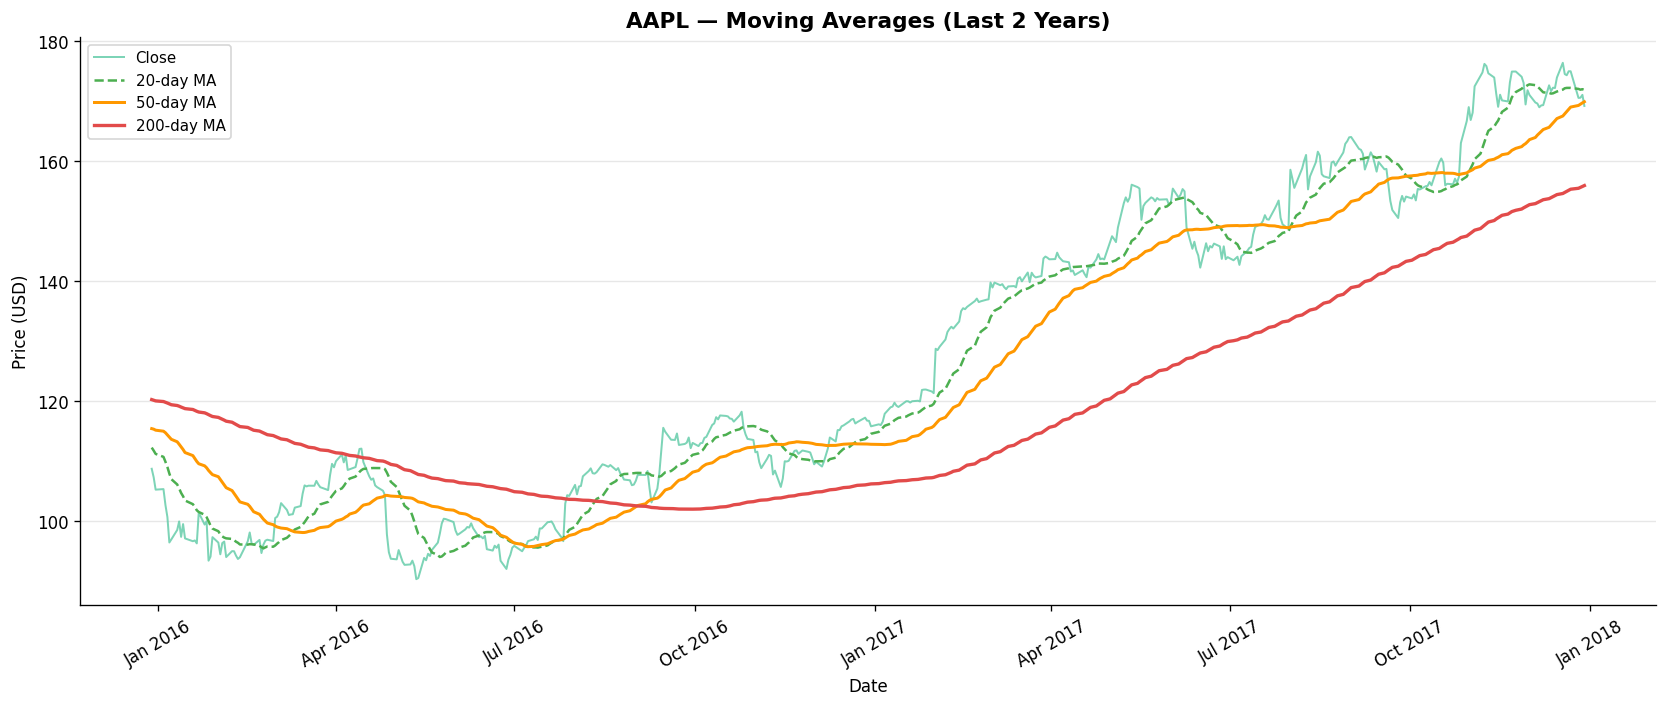

In [10]:
df["MA_20"]  = df["close"].rolling(window=20).mean()
df["MA_50"]  = df["close"].rolling(window=50).mean()
df["MA_200"] = df["close"].rolling(window=200).mean()

# Plot last 2 years for clarity
cutoff = df["date"].max() - pd.DateOffset(years=2)
df2 = df[df["date"] >= cutoff]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df2["date"], df2["close"],   color="#5DCAA5", lw=1.2, alpha=0.8, label="Close")
ax.plot(df2["date"], df2["MA_20"],   color="#4CAF50", lw=1.5, ls="--",   label="20-day MA")
ax.plot(df2["date"], df2["MA_50"],   color="#FF9800", lw=1.8,            label="50-day MA")
ax.plot(df2["date"], df2["MA_200"],  color="#E24B4A", lw=2.0,            label="200-day MA")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
ax.set_title(f"{TICKER} — Moving Averages (Last 2 Years)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/level2/timeseries_plots/03_moving_averages.png")
plt.show()

## Step 6 — Bollinger Bands

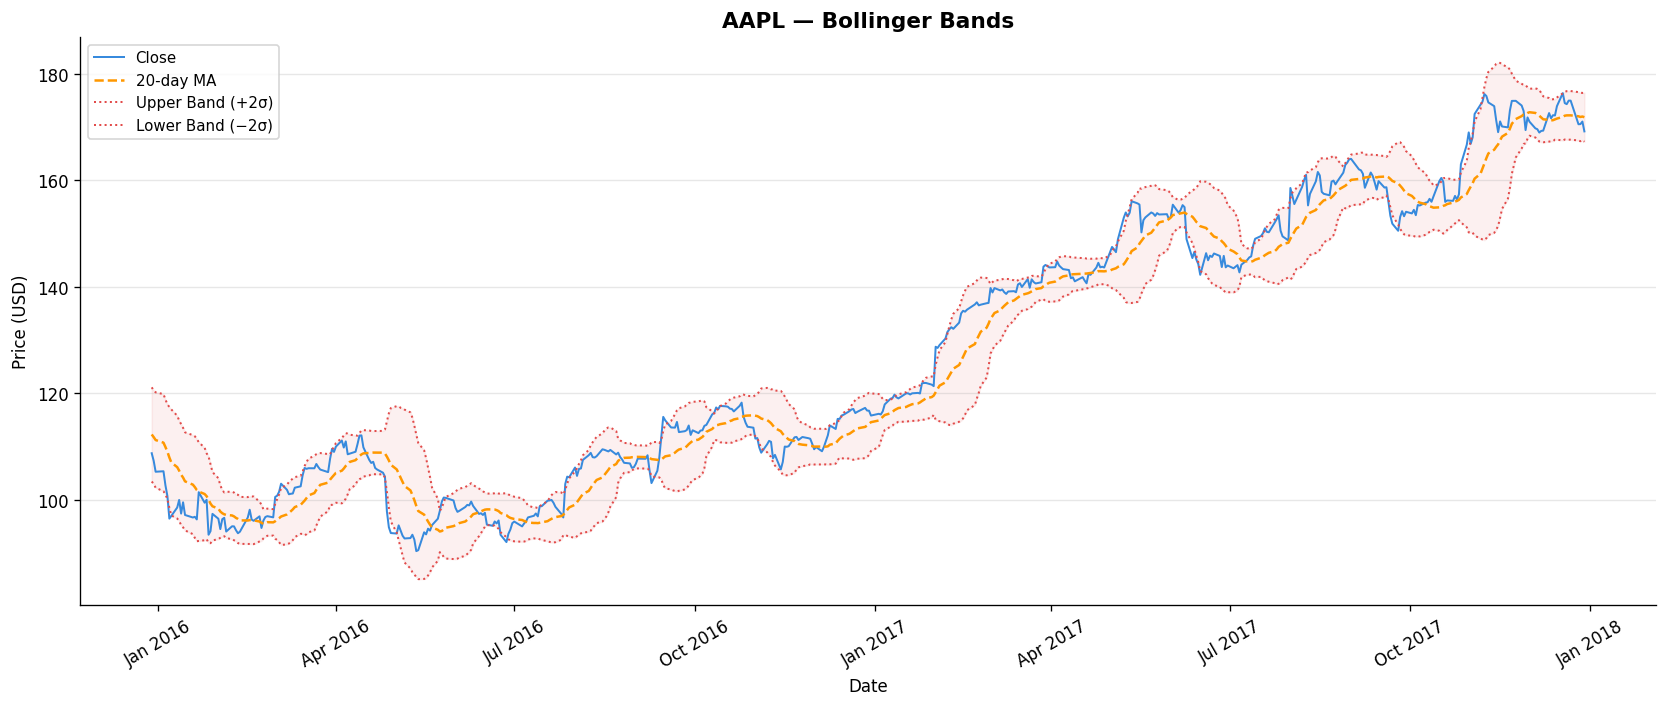

In [11]:
df["BB_upper"] = df["MA_20"] + 2 * df["close"].rolling(20).std()
df["BB_lower"] = df["MA_20"] - 2 * df["close"].rolling(20).std()

df2 = df[df["date"] >= cutoff]
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df2["date"], df2["close"],    color="#378ADD", lw=1.2, label="Close")
ax.plot(df2["date"], df2["MA_20"],    color="#FF9800", lw=1.5, ls="--", label="20-day MA")
ax.plot(df2["date"], df2["BB_upper"], color="#E24B4A", lw=1.2, ls=":", label="Upper Band (+2σ)")
ax.plot(df2["date"], df2["BB_lower"], color="#E24B4A", lw=1.2, ls=":", label="Lower Band (−2σ)")
ax.fill_between(df2["date"], df2["BB_lower"], df2["BB_upper"], alpha=0.08, color="#E24B4A")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
ax.set_title(f"{TICKER} — Bollinger Bands", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/level2/timeseries_plots/04_bollinger_bands.png")
plt.show()

## Step 7 — Seasonal Decomposition (statsmodels)

Weekly series: 209 data points


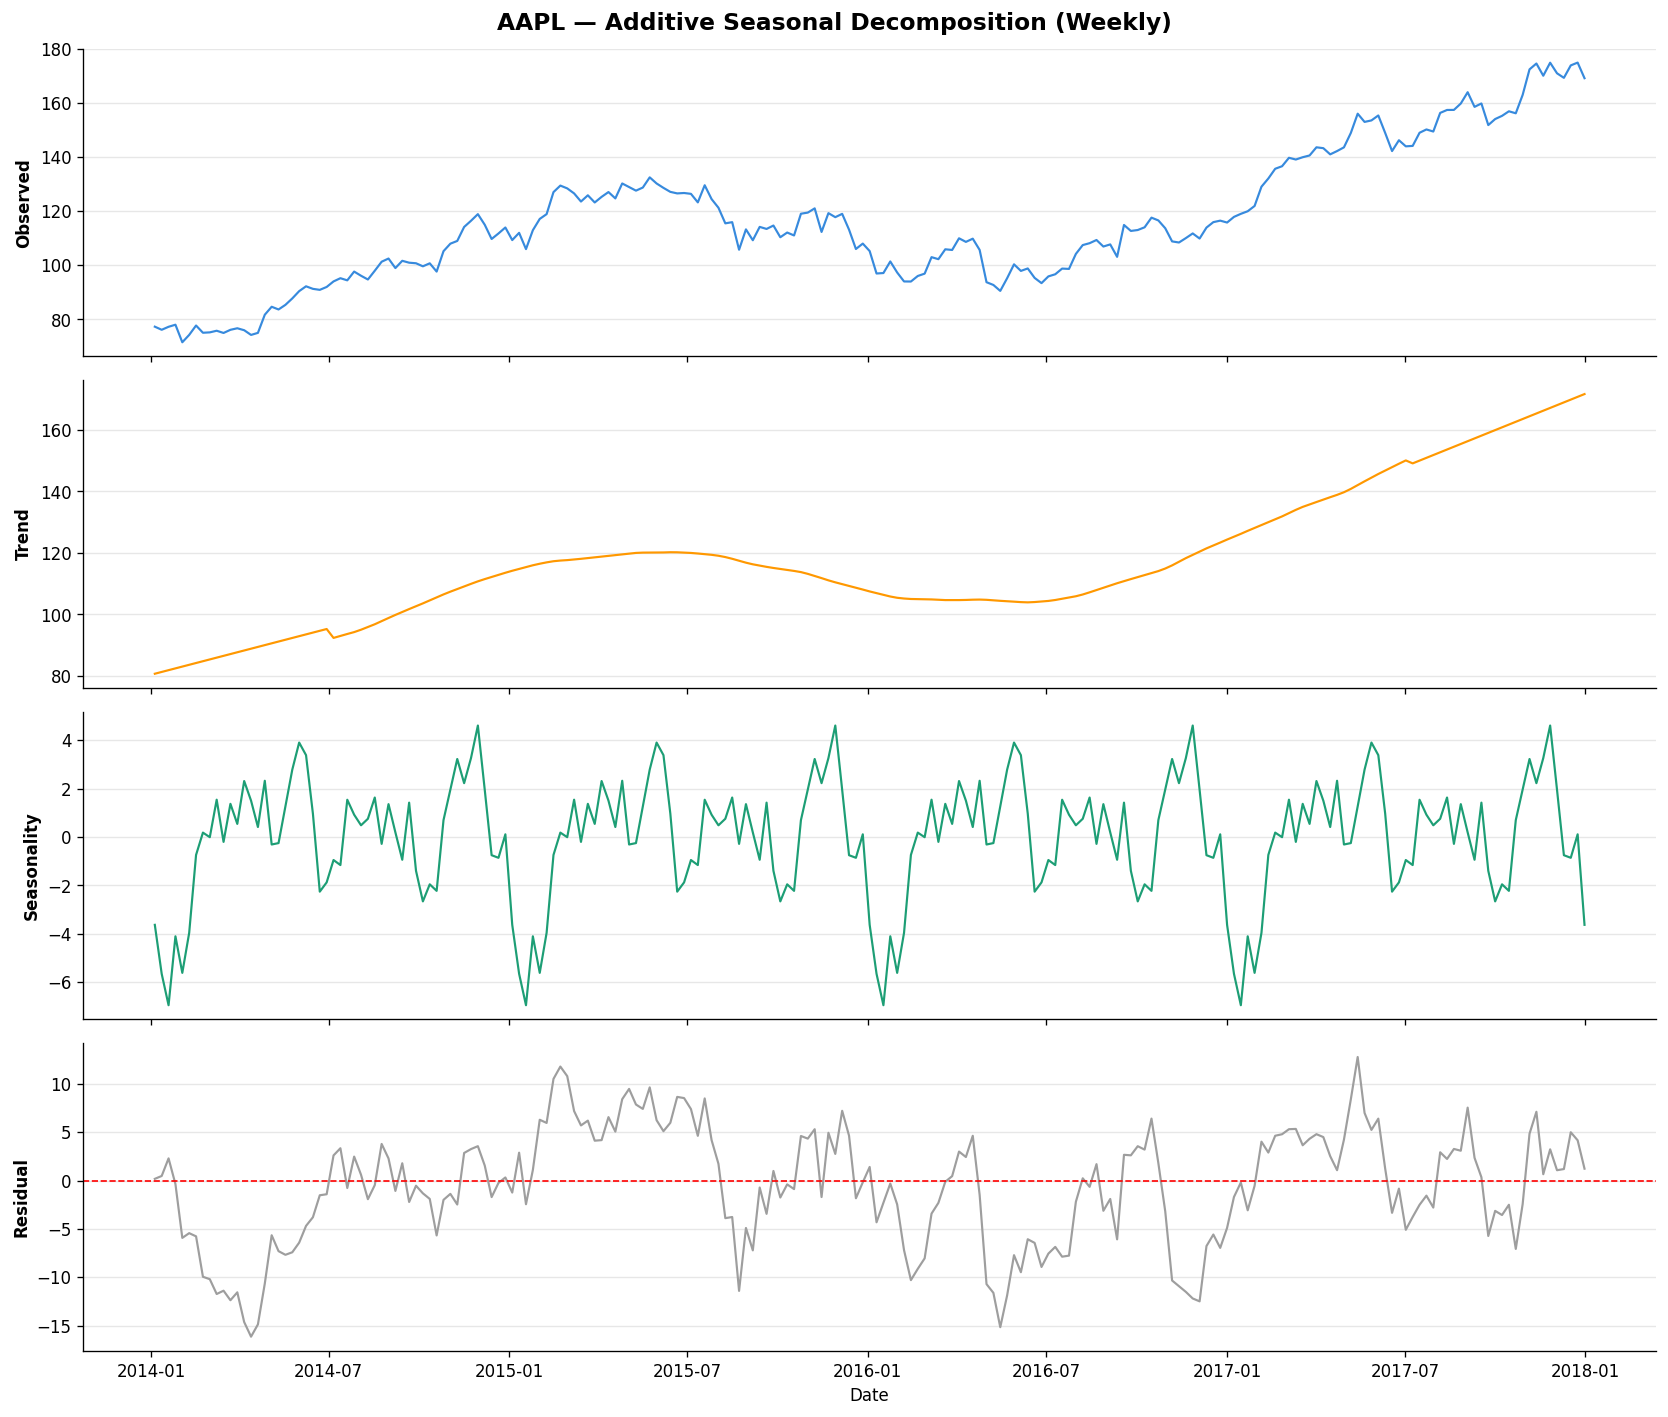

In [12]:
# Resample to weekly close prices (cleaner decomposition)
df_weekly = df.set_index("date")["close"].resample("W").last().dropna()
print(f"Weekly series: {len(df_weekly)} data points")

decomp = seasonal_decompose(df_weekly, model="additive", period=52, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"{TICKER} — Additive Seasonal Decomposition (Weekly)",
             fontsize=14, fontweight="bold")

components = [
    (decomp.observed,  "Observed",   "#378ADD"),
    (decomp.trend,     "Trend",      "#FF9800"),
    (decomp.seasonal,  "Seasonality","#1D9E75"),
    (decomp.resid,     "Residual",   "#9E9E9E"),
]
for ax, (comp, label, color) in zip(axes, components):
    ax.plot(comp.index, comp.values, color=color, lw=1.3)
    ax.set_ylabel(label, fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    if label == "Residual":
        ax.axhline(0, color="red", ls="--", lw=1)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("outputs/level2/timeseries_plots/05_seasonal_decomposition.png")
plt.show()

## Step 8 — Monthly Return Patterns

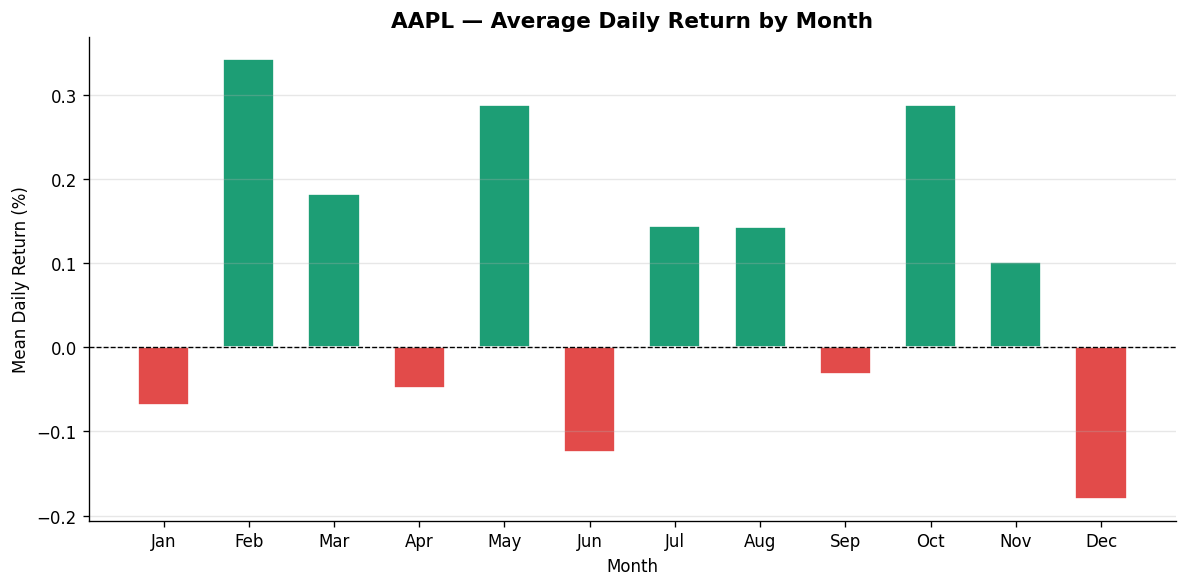

In [13]:
df["month"] = df["date"].dt.month
monthly_returns = df.groupby("month")["daily_return"].mean()
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
colors_m = ["#E24B4A" if v < 0 else "#1D9E75" for v in monthly_returns]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1,13), monthly_returns.values, color=colors_m, edgecolor="white", width=0.6)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_xlabel("Month"); ax.set_ylabel("Mean Daily Return (%)")
ax.set_title(f"{TICKER} — Average Daily Return by Month", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/level2/timeseries_plots/06_monthly_patterns.png")
plt.show()